In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [49]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
searches = {
    # 'plan': f'{data_dir}/user_data/*exp4*/*r0*t0plan*.json',
    'shortcut': f'{data_dir}/user_data/*exp4*/*shortcut*.json',
}

valid_files = data_loading.get_valid_files(searches)

shortcut: 28/36 valid files


In [50]:
valid_files

['/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=493121589_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=3372424394_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=2764371760_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=4233470130_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=3867046102_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=1012357475_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=756885089_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_use

In [3]:
import glob

valid_files = glob.glob("data2/*.json")
len(valid_files), valid_files

(30,
 ['data2/user=791091936_name=exp_debug=1.json',
  'data2/user=4253778466_name=exp_debug=1.json',
  'data2/user=2445391523_name=exp_debug=1.json',
  'data2/user=2776631717_name=exp_debug=1.json',
  'data2/user=823768836_name=exp_debug=1.json',
  'data2/user=1101454868_name=exp_debug=1.json',
  'data2/user=3583974017_name=exp_debug=1.json',
  'data2/user=2732015494_name=exp_debug=1.json',
  'data2/user=2640537153_name=exp_debug=1.json',
  'data2/user=4292174514_name=exp_debug=1.json',
  'data2/user=36491733_name=exp_debug=1.json',
  'data2/user=1110453748_name=exp_debug=1.json',
  'data2/user=57777321_name=exp_debug=1.json',
  'data2/user=1796454843_name=exp_debug=1.json',
  'data2/user=3822998586_name=exp_debug=1.json',
  'data2/user=4048609425_name=exp_debug=1.json',
  'data2/user=2195168518_name=exp_debug=1.json',
  'data2/user=237405895_name=exp_debug=1.json',
  'data2/user=2298976599_name=exp_debug=1.json',
  'data2/user=594077087_name=exp_debug=1.json',
  'data2/user=346124486

In [4]:
import json
def read_dicts_from_file(filename='data.json'):
    dictionaries = []
    with open(filename, 'r') as f:
        for line in f:
            # Parse each line as a JSON object (dictionary) and append it to the list
            dictionaries.append(json.loads(line.strip()))
    return dictionaries

file = valid_files[0]
data_dicts = read_dicts_from_file(file)
file, len(data_dicts)

('data2/user=791091936_name=exp_debug=1.json', 499)

In [12]:
keys=set()
from datetime import datetime

def get_block_idx(stage, data_dicts):
    # says which current block we're in
    # e.g. 3. from [0, 1, 3, 2]
    block_order = datum['metadata']['block_metadata']['idx']
    
    # for 3, I'd want to get but 2.
    # how do we get that?
    block_idx = data_dicts[-1]['user_storage']['block_order_to_idx'][str(block_order)]
    return block_idx

def stage_name(datum, data_dicts):
    block_idx = get_block_idx(datum, data_dicts)
    block_name = datum['metadata']['block_metadata'].get('short', 'generic')
    stage_name = datum['metadata']['maze']
    eval = datum['metadata']['eval']
    return f'block {block_idx}. {block_name}: {stage_name}. eval={eval}'

for datum in data_dicts:
    try:
        maze = datum['metadata']['maze']
    except:
        continue
    # if 'practice' in maze: continue
    r = datum['metadata']['block_metadata'].get('reversal', None)
    image_seen_time_str = datum['data']['image_seen_time']
    image_seen_time = datetime.strptime(image_seen_time_str, '%Y-%m-%dT%H:%M:%S.%fZ')
    formatted_time = image_seen_time.strftime('%H:%M:%S')

    user_id = datum['user_data']['user_id']
    idx = datum['stage_idx']
    key = f"{stage_name(datum, data_dicts)}"
    if not key in keys:
        keys.add(key)
        print(idx, '-'*10)
        print(key)
        # print(formatted_time)
        print()
        # print(len(keys))

2 ----------
block 1. generic: big_practice_maze_(F,F). eval=False

4 ----------
block 1. generic: big_practice_maze_(F,F). eval=True

6 ----------
block 2. plan_long_F,F: big_m4_maze_long_(F,F). eval=False

8 ----------
block 2. plan_long_F,F: big_m4_maze_long_eval_same_(F,F). eval=True

9 ----------
block 2. plan_long_F,F: big_m4_maze_long_eval_diff_(F,F). eval=True

11 ----------
block 3. plan_long_F,T: big_m4_maze_long_(F,T). eval=False

13 ----------
block 3. plan_long_F,T: big_m4_maze_long_eval_same_(F,T). eval=True

14 ----------
block 3. plan_long_F,T: big_m4_maze_long_eval_diff_(F,T). eval=True

16 ----------
block 4. plan_long_T,F: big_m4_maze_long_(T,F). eval=False

18 ----------
block 4. plan_long_T,F: big_m4_maze_long_eval_same_(T,F). eval=True

19 ----------
block 4. plan_long_T,F: big_m4_maze_long_eval_diff_(T,F). eval=True

21 ----------
block 5. plan_short_F,T: big_m4_maze_short_(F,T). eval=False

23 ----------
block 5. plan_short_F,T: big_m4_maze_short_eval_same_(F,T)

In [6]:
import jax
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import mazes
from analysis import housemaze_utils
from analysis import data_loading
from experiment_utils import SuccessTrackingAutoResetWrapper

dummy_env_params = housemaze_utils.get_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_utils.task_objects)
base_env = maze.HouseMaze(
    task_runner=task_runner,
    num_categories=200,
)
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


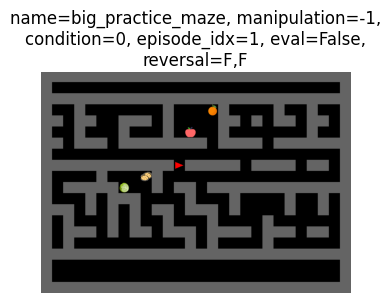

0
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 486.0


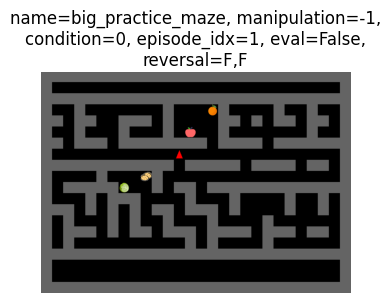

1
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 658.0


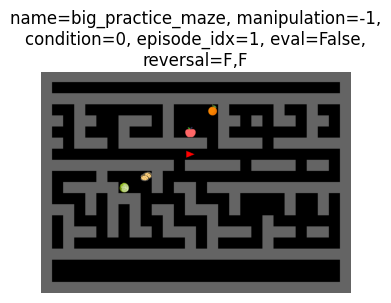

2
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 143.0


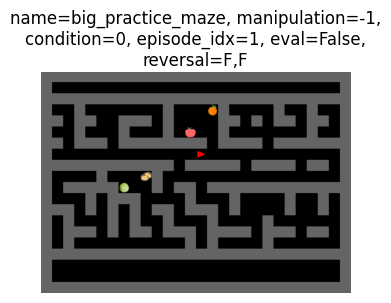

3
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 149.0


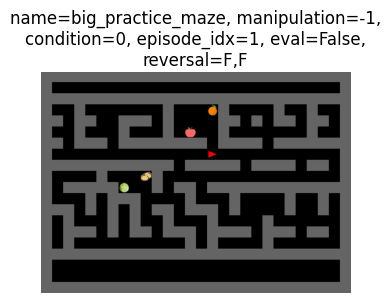

4
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 203.0


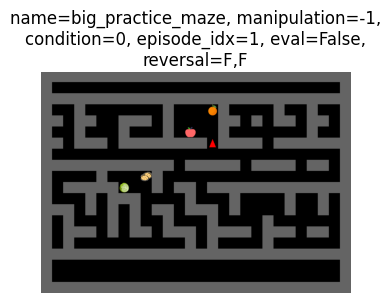

5
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 162.0


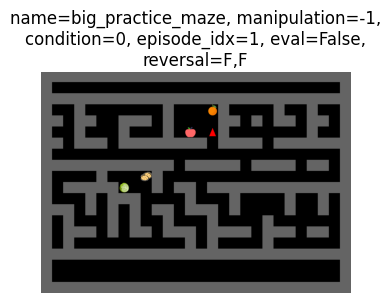

6
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 151.0


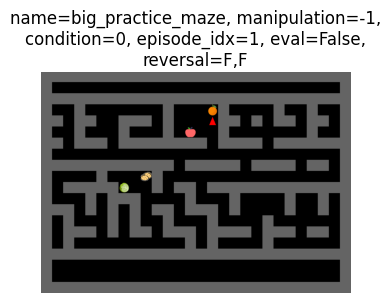

7
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 148.0


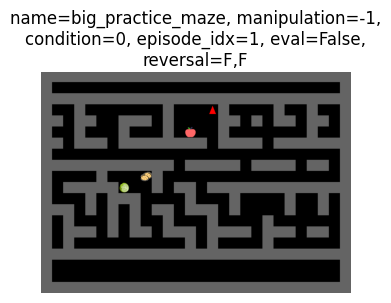

8
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=1, eval=False, reversal=F,F
RT: 716.0


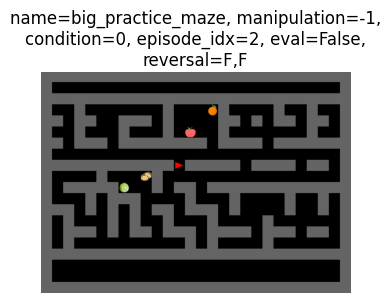

9
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 379.0


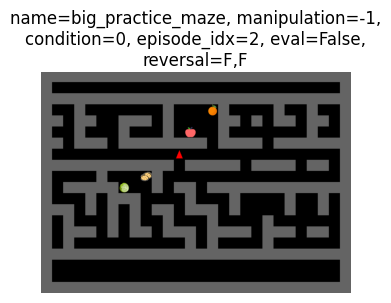

10
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 202.0


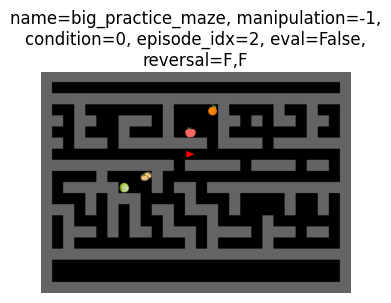

11
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 147.0


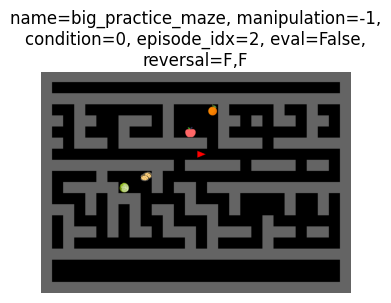

12
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 126.0


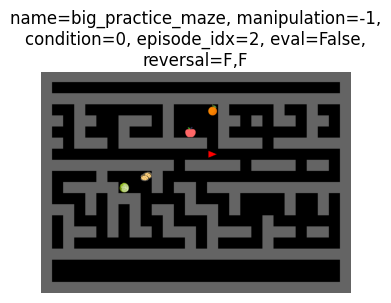

13
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 142.0


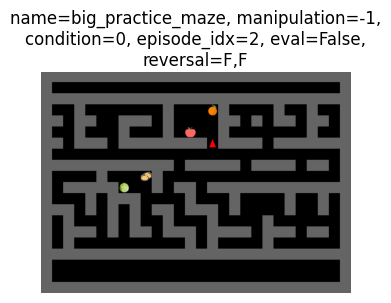

14
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 163.0


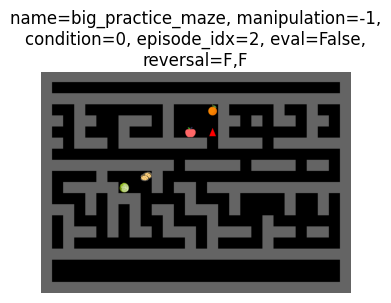

15
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 161.0


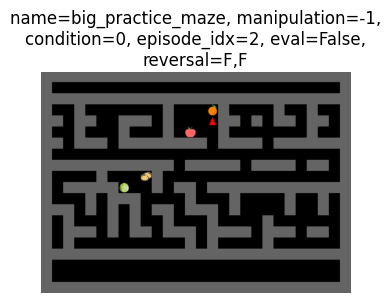

16
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 113.0


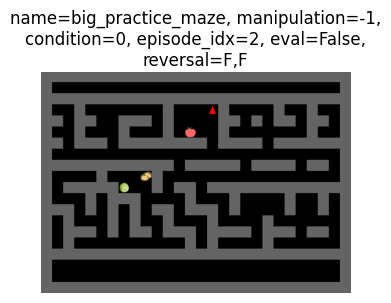

17
TITLE: name=big_practice_maze, manipulation=-1, condition=0, episode_idx=2, eval=False, reversal=F,F
RT: 0.0


In [82]:
from analysis.data_loading import dict_to_string, get_timestep, reversal_label, compute_reaction_time
from analysis.housemaze_utils import housemaze_render_fn
import matplotlib.pyplot as plt
from datetime import datetime

def get_block_stage_description(datum):
    ####################
    # block information
    ####################
    block_metadata = datum['metadata']['block_metadata']
    # e.g. manipulation = 4
    block_manipulation = block_metadata.get('manipulation', -1)
    # e.g. desc = 'off-task object regular'
    block_desc = block_metadata.get('desc', 'unknown')

    ####################
    # stage information
    ####################
    reversal = datum['metadata']['block_metadata'].get('reversal', [False, False])
    return dict(
        # maze=datum['metadata'].get('maze'),
        name=datum['name'],
        manipulation=block_manipulation,
        condition=datum['metadata'].get('condition', 0),
        # block=block_desc,
        episode_idx=datum['metadata']['nepisodes'],
        eval=datum['metadata']['eval'],
        reversal=reversal_label(reversal),
    )
# let's just print out the first few time-step to see what they look like
keys = set()
# nidx = 2
nidx = len(data_dicts)
changes = 0
for idx in range(nidx):
    datum = data_dicts[idx]
    if 'finished' in datum.keys(): continue
    if not 'image_seen_time' in datum['data']: continue
    
    # get the information describing block x stage pairs. you can edit this function if you want
    info = get_block_stage_description(datum)
    title = dict_to_string(info)
    # if 'practice' in title: continue

    # if not('diff' in datum['name'] or 'same' in datum['name']): continue

    if not title in keys:
        print("="*100)
        changes += 1
        keys.add(title)
    
    timestep = get_timestep(datum, example_web_timestep)
    image = housemaze_render_fn(timestep.state)
    # action_taken: int = datum['action_idx']

    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(title, wrap=True)
    plt.show()

    print(idx)
    # print(datum['name'])
    image_seen_time_str = datum['data']['image_seen_time']
    image_seen_time = datetime.strptime(image_seen_time_str, '%Y-%m-%dT%H:%M:%S.%fZ')
    formatted_time = image_seen_time.strftime('%H:%M:%S')
    reaction_time = compute_reaction_time(datum)
    print('TITLE:', title)
    # print(formatted_time)
    print('RT:', reaction_time)


In [42]:
datum = data_dicts[idx-1]